# Assignment 3 — Feature Engineering Pipeline

## Objective

To develop and evaluate machine learning models using the faculty-provided Adult Income dataset, compare models trained on raw and engineered features, and construct a complete feature engineering and preprocessing pipeline.

## Experiment Workflow

1. Train Logistic Regression and Random Forest models using raw features.
2. Perform controlled hyperparameter experiments on the raw-feature models.
3. Create and evaluate engineered features.
4. Train Logistic Regression and Random Forest models using engineered features.
5. Construct complete scikit-learn pipelines combining feature engineering, preprocessing, and model training.
6. Track datasets, parameters, metrics, and models using MLflow.
7. Compare all experiments and identify the best configuration.
8. Verify reproducibility by loading the final model from MLflow.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- MLflow

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

import mlflow
import mlflow.sklearn
from mlflow.tracking import MlflowClient

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# MLflow Tracking Server
MLFLOW_TRACKING_URI = "http://127.0.0.1:5000"

# MLflow Experiment
MLFLOW_EXPERIMENT_NAME = "Assignment 3: Feature Engineering and Pipeline"

# Reproducibility
RANDOM_STATE = 42

# Connect to centralized MLflow server
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

print("Libraries imported successfully.")
print("MLflow version:", mlflow.__version__)
print("MLflow Tracking URI:", mlflow.get_tracking_uri())
print("Random State:", RANDOM_STATE)

DATA_PATH = "../data/adult.csv"
TARGET_COLUMN = "income"

Libraries imported successfully.
MLflow version: 3.15.1
MLflow Tracking URI: http://127.0.0.1:5000
Random State: 42


## 2. MLflow Experiment and Dataset Setup

MLflow is used to track all experiments in Assignment 3.

The MLflow experiment is configured before model experimentation begins. 
Whenever the complete notebook is rerun, previous runs and logged models belonging to this experiment are removed so that the MLflow UI contains only the results from the current notebook execution.

The experiment itself is preserved.

This ensures that each complete notebook execution produces a clean and reproducible MLflow experiment history.

In [ ]:
import mlflow
from mlflow.tracking import MlflowClient

# Connect to MLflow Tracking Server
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

client = MlflowClient()

# Find existing experiment
experiment = client.get_experiment_by_name(
    MLFLOW_EXPERIMENT_NAME
)

if experiment is not None:

    experiment_id = experiment.experiment_id

    print("Existing MLflow experiment found.")
    print("Experiment ID:", experiment_id)

    # ----------------------------------------
    # Delete previously logged models
    # ----------------------------------------

    logged_models = client.search_logged_models(
        experiment_ids=[experiment_id],
        max_results=1000
    )

    deleted_models = 0

    for model in logged_models:
        client.delete_logged_model(
            model.model_id
        )
        deleted_models += 1

    # ----------------------------------------
    # Delete previous runs
    # ----------------------------------------

    runs = client.search_runs(
        experiment_ids=[experiment_id],
        max_results=1000
    )

    deleted_runs = 0

    for run in runs:
        client.delete_run(
            run.info.run_id
        )
        deleted_runs += 1

    print("Previous logged models deleted:", deleted_models)
    print("Previous MLflow runs deleted:", deleted_runs)

else:

    # Create experiment only if it does not exist
    experiment_id = client.create_experiment(
        MLFLOW_EXPERIMENT_NAME
    )

    print("New MLflow experiment created.")


# ----------------------------------------
# Set experiment as active
# ----------------------------------------

mlflow.set_experiment(
    MLFLOW_EXPERIMENT_NAME
)

print("\nMLflow experiment configured successfully.")
print("Experiment:", MLFLOW_EXPERIMENT_NAME)
print("Experiment ID:", experiment_id)

Existing MLflow experiment found.
Experiment ID: 3
Previous logged models deleted: 2
Previous MLflow runs deleted: 14

MLflow experiment configured successfully.
Experiment: Assignment 3: Feature Engineering and Pipeline
Experiment ID: 3


## 3. Load the Dataset

The dataset will be loaded without modifying the original data. All feature engineering and preprocessing operations will be performed in later stages so that the raw dataset remains available for baseline experiments and comparison.

In [3]:
# Load the dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

df.head()

# ----------------------------------------
# Create MLflow dataset object
# ----------------------------------------

adult_dataset = mlflow.data.from_pandas(
    df,
    name="Adult Income Dataset",
    targets=TARGET_COLUMN
)

print("\nMLflow dataset created successfully.")
print("Dataset Name:", adult_dataset.name)
print("Dataset Digest:", adult_dataset.digest)

Dataset loaded successfully.
Dataset shape: (48842, 15)

MLflow dataset created successfully.
Dataset Name: Adult Income Dataset
Dataset Digest: 5dcb7f0a


## 4. Dataset Understanding

The raw Adult Income dataset is inspected to understand its structure before preprocessing and feature engineering.

The following aspects are examined:

- Dataset dimensions
- Column names and data types
- Numerical features
- Categorical features
- Target variable

The original dataset is kept unchanged during this stage.

In [4]:
# Display dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

# Identify numerical and categorical features
numerical_features = df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = df.select_dtypes(
    include=["object"]
).columns.tolist()

# Remove target from feature lists
numerical_features.remove(TARGET_COLUMN) if TARGET_COLUMN in numerical_features else None
categorical_features.remove(TARGET_COLUMN) if TARGET_COLUMN in categorical_features else None

print("\nTarget Column:")
print(TARGET_COLUMN)

print("\nNumerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nTotal Input Features:", len(numerical_features) + len(categorical_features))

Dataset Shape: (48842, 15)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB

Target Column:
income

Num

## 5. Data Quality Analysis

The raw dataset is checked for missing and unknown values before model training.

Two types of missing information are examined separately:

1. **NaN values** — explicitly represented missing values.
2. **Unknown values (`?`)** — categorical values represented using the `?` symbol in the original dataset.

The original dataset will not be modified during this analysis.

In [5]:
# Check for NaN values
nan_counts = df.isnull().sum()

print("Missing values (NaN):")
display(nan_counts)

# Check for unknown values represented by '?'
unknown_counts = (df == "?").sum()

print("\nUnknown values ('?'):")
display(unknown_counts)

# Show columns containing unknown values
unknown_summary = unknown_counts[unknown_counts > 0]

print("\nColumns containing unknown values:")
display(unknown_summary)

Missing values (NaN):


age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


Unknown values ('?'):


age                   0
workclass          2799
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2809
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      857
income                0
dtype: int64


Columns containing unknown values:


workclass         2799
occupation        2809
native-country     857
dtype: int64

## 6. Target Variable Analysis

The target variable `income` is analyzed to understand the distribution of the two income classes.

Since the classes are not evenly distributed, stratified train-test splitting will be used later to preserve approximately the same class proportions in both the training and testing datasets.

Target Class Counts:


income
<=50K    37155
>50K     11687
Name: count, dtype: int64


Target Class Proportions:


income
<=50K    0.760718
>50K     0.239282
Name: proportion, dtype: float64

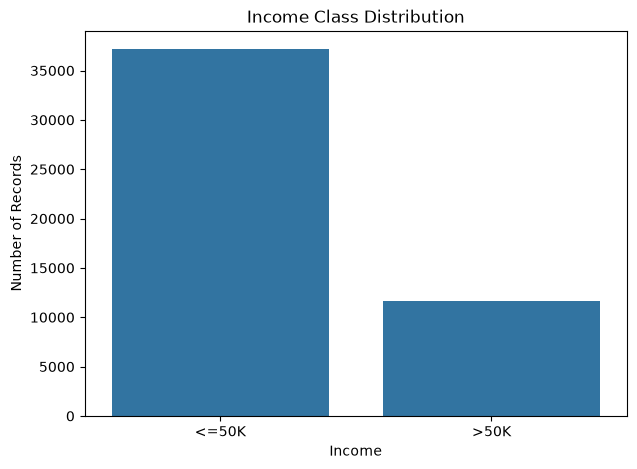

In [6]:
# Analyze target distribution

target_counts = df[TARGET_COLUMN].value_counts()
target_proportions = df[TARGET_COLUMN].value_counts(normalize=True)

print("Target Class Counts:")
display(target_counts)

print("\nTarget Class Proportions:")
display(target_proportions)

# Visualize target distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=TARGET_COLUMN
)

plt.title("Income Class Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Records")

plt.show()

## 7. Train/Test Split

The dataset is divided into training and testing sets using an 80:20 split.

A fixed random state of 42 is used to ensure reproducibility across all experiments.

Stratification is applied using the target variable so that the class distribution of `income` remains approximately the same in both training and testing datasets.

This same split will be reused for:

- Raw-feature Logistic Regression
- Raw-feature Random Forest
- Feature-engineered Logistic Regression
- Feature-engineered Random Forest
- Pipeline-based models

In [7]:
# Separate features and target

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Create a fixed train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting set:")
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True))

Training set:
X_train: (39073, 14)
y_train: (39073,)

Testing set:
X_test : (9769, 14)
y_test : (9769,)

Training target distribution:


income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64


Testing target distribution:


income
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64

## 8. Raw-Feature Preprocessing

Before training the baseline models, the original 14 features are preprocessed without applying any custom feature engineering.

### Numerical Features

The numerical features are processed using:

1. Median imputation
2. Standardization using `StandardScaler`

### Categorical Features

The categorical features contain unknown values represented by `?`.

These values will be treated as missing values and processed using:

1. Replace `?` with missing values
2. Most-frequent imputation
3. One-hot encoding

The preprocessing is fitted only on the training data and then applied to both training and testing data to prevent data leakage.

No engineered features are introduced at this stage.

In [8]:
# Create copies so the original dataset remains unchanged
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Replace unknown '?' values with NaN
X_train_raw = X_train_raw.replace("?", np.nan)
X_test_raw = X_test_raw.replace("?", np.nan)

# Numerical preprocessing
raw_numerical_pipeline = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Categorical preprocessing
raw_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combine preprocessing
raw_preprocessor = ColumnTransformer(
    transformers=[
        ("numerical", raw_numerical_pipeline, numerical_features),
        ("categorical", raw_categorical_pipeline, categorical_features),
    ]
)

# Fit only on training data
X_train_raw_transformed = raw_preprocessor.fit_transform(X_train_raw)

# Transform testing data using the fitted preprocessor
X_test_raw_transformed = raw_preprocessor.transform(X_test_raw)

print("Raw-feature preprocessing completed successfully.")

print("\nOriginal training features:", X_train_raw.shape)

print("Transformed training features:", X_train_raw_transformed.shape)

print("\nOriginal testing features:", X_test_raw.shape)

print("Transformed testing features:", X_test_raw_transformed.shape)

Raw-feature preprocessing completed successfully.

Original training features: (39073, 14)
Transformed training features: (39073, 105)

Original testing features: (9769, 14)
Transformed testing features: (9769, 105)


## 9. Raw-Feature Logistic Regression Baseline

A Logistic Regression model is trained using the original dataset features without any custom feature engineering.

The model uses the preprocessed raw features generated in the previous step.

### Configuration

- Model: Logistic Regression
- C: 1.0
- Maximum iterations: 1000
- Random state: 42

The model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification report
- Confusion matrix

Raw Logistic Regression Baseline
--------------------------------
Accuracy : 0.8524
Precision: 0.7414
Recall   : 0.5885
F1-Score : 0.6562
ROC-AUC  : 0.9042

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      7431
        >50K       0.74      0.59      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.76      0.78      9769
weighted avg       0.85      0.85      0.85      9769



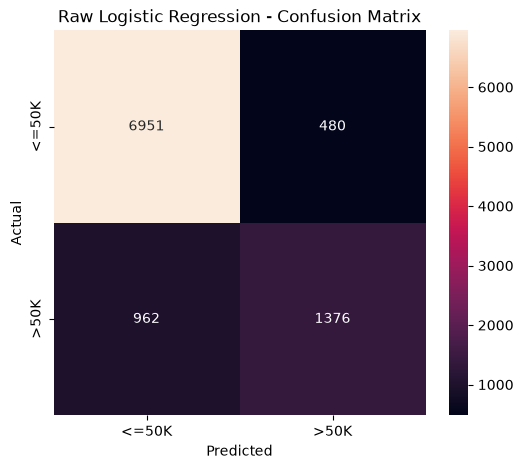

In [9]:
# Create Logistic Regression baseline model
raw_lr_baseline = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)

# Train the model
raw_lr_baseline.fit(
    X_train_raw_transformed,
    y_train
)

# Generate predictions
raw_lr_predictions = raw_lr_baseline.predict(
    X_test_raw_transformed
)

# Generate prediction probabilities
raw_lr_probabilities = raw_lr_baseline.predict_proba(
    X_test_raw_transformed
)[:, 1]

# Calculate evaluation metrics
raw_lr_accuracy = accuracy_score(
    y_test,
    raw_lr_predictions
)

raw_lr_precision = precision_score(
    y_test,
    raw_lr_predictions,
    pos_label=">50K"
)

raw_lr_recall = recall_score(
    y_test,
    raw_lr_predictions,
    pos_label=">50K"
)

raw_lr_f1 = f1_score(
    y_test,
    raw_lr_predictions,
    pos_label=">50K"
)

raw_lr_roc_auc = roc_auc_score(
    y_test,
    raw_lr_probabilities
)

print("Raw Logistic Regression Baseline")
print("--------------------------------")
print(f"Accuracy : {raw_lr_accuracy:.4f}")
print(f"Precision: {raw_lr_precision:.4f}")
print(f"Recall   : {raw_lr_recall:.4f}")
print(f"F1-Score : {raw_lr_f1:.4f}")
print(f"ROC-AUC  : {raw_lr_roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, raw_lr_predictions))

cm = confusion_matrix(y_test, raw_lr_predictions)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"],
)

plt.title("Raw Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 10. Raw-Feature Random Forest Baseline

A Random Forest classifier is trained using the original dataset features without custom feature engineering.

The model uses the same preprocessed raw features and the same fixed training/testing split used for Logistic Regression.

### Configuration

- Model: Random Forest Classifier
- Number of estimators: 100
- Random state: 42

The model is evaluated using the same metrics as the Logistic Regression baseline so that the two model families can be compared fairly.

Raw Random Forest Baseline
--------------------------
Accuracy : 0.8602
Precision: 0.7430
Recall   : 0.6356
F1-Score : 0.6851
ROC-AUC  : 0.9038

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.64      0.69      2338

    accuracy                           0.86      9769
   macro avg       0.82      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



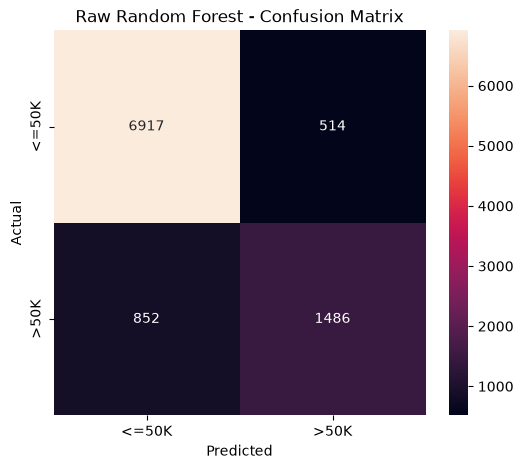

In [10]:
# Create Random Forest baseline model
raw_rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Train the model
raw_rf_baseline.fit(
    X_train_raw_transformed,
    y_train
)

# Generate predictions
raw_rf_predictions = raw_rf_baseline.predict(
    X_test_raw_transformed
)

# Generate prediction probabilities for ROC-AUC
raw_rf_probabilities = raw_rf_baseline.predict_proba(
    X_test_raw_transformed
)[:, 1]

# Calculate evaluation metrics
raw_rf_accuracy = accuracy_score(
    y_test,
    raw_rf_predictions
)

raw_rf_precision = precision_score(
    y_test,
    raw_rf_predictions,
    pos_label=">50K"
)

raw_rf_recall = recall_score(
    y_test,
    raw_rf_predictions,
    pos_label=">50K"
)

raw_rf_f1 = f1_score(
    y_test,
    raw_rf_predictions,
    pos_label=">50K"
)

raw_rf_roc_auc = roc_auc_score(
    y_test,
    raw_rf_probabilities
)

print("Raw Random Forest Baseline")
print("--------------------------")
print(f"Accuracy : {raw_rf_accuracy:.4f}")
print(f"Precision: {raw_rf_precision:.4f}")
print(f"Recall   : {raw_rf_recall:.4f}")
print(f"F1-Score : {raw_rf_f1:.4f}")
print(f"ROC-AUC  : {raw_rf_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        raw_rf_predictions
    )
)

# Confusion matrix
cm = confusion_matrix(
    y_test,
    raw_rf_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["<=50K", ">50K"],
    yticklabels=["<=50K", ">50K"]
)

plt.title("Raw Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 11. Reusable Model Evaluation and MLflow Logging

A reusable function is created to standardize model training, evaluation, and MLflow experiment tracking.

For every experiment, the function records:

### Dataset
- Adult Income Dataset
- Training context

### Parameters
- Model configuration
- Experiment type
- Feature engineering status
- Hyperparameters

### Metrics
- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

Using a common function ensures that all experiments are evaluated and tracked consistently.

In [11]:
def train_evaluate_log_model(
    model,
    X_train_data,
    X_test_data,
    y_train_data,
    y_test_data,
    run_name,
    experiment_type,
    feature_engineering,
    model_params=None,
):
    """
    Train, evaluate, and log a machine learning model using MLflow.
    """

    # Start MLflow run
    with mlflow.start_run(run_name=run_name):

        # Log dataset used for training
        mlflow.log_input(adult_dataset, context="training")

        # Log general experiment information
        mlflow.log_param("experiment_type", experiment_type)
        mlflow.log_param("feature_engineering", feature_engineering)

        # Log model parameters
        if model_params:
            for parameter, value in model_params.items():
                mlflow.log_param(parameter, value)

        # Train model
        model.fit(X_train_data, y_train_data)

        # Generate predictions
        predictions = model.predict(X_test_data)

        # Generate probabilities for ROC-AUC
        probabilities = model.predict_proba(X_test_data)[:, 1]

        # Calculate metrics
        accuracy = accuracy_score(y_test_data, predictions)

        precision = precision_score(y_test_data, predictions, pos_label=">50K")

        recall = recall_score(y_test_data, predictions, pos_label=">50K")

        f1 = f1_score(y_test_data, predictions, pos_label=">50K")

        roc_auc = roc_auc_score(y_test_data, probabilities)

        # Log metrics
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)

        # Print results
        print(f"Run: {run_name}")
        print("-" * len(f"Run: {run_name}"))

        print(f"Accuracy : {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-Score : {f1:.4f}")
        print(f"ROC-AUC  : {roc_auc:.4f}")

        return {
            "run_id": mlflow.active_run().info.run_id,
            "run_name": run_name,
            "model": model,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "roc_auc": roc_auc,
        }

## 12. Raw-Feature Baseline Experiments in MLflow

The two baseline models trained using the original features are now tracked in MLflow.

### Experiment 1
- Model: Logistic Regression
- Features: Original features
- Feature engineering: Disabled
- C: 1.0

### Experiment 2
- Model: Random Forest
- Features: Original features
- Feature engineering: Disabled
- Number of estimators: 100

Both experiments use the same fixed train/test split and the same evaluation metrics.

In [12]:
# ============================================
# Raw Logistic Regression Baseline
# ============================================

raw_lr_result = train_evaluate_log_model(
    model=LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_data=X_train_raw_transformed,
    X_test_data=X_test_raw_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Raw_Baseline_C1.0",
    experiment_type="raw_baseline",
    feature_engineering="disabled",
    model_params={
        "model": "LogisticRegression",
        "C": 1.0,
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    }
)

print("\n")


# ============================================
# Raw Random Forest Baseline
# ============================================

raw_rf_result = train_evaluate_log_model(
    model=RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_data=X_train_raw_transformed,
    X_test_data=X_test_raw_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Raw_Baseline_100",
    experiment_type="raw_baseline",
    feature_engineering="disabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 100,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
)

d:\College\3rd_Year\MLOPS\.mlops\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


Run: LR_Raw_Baseline_C1.0
-------------------------
Accuracy : 0.8524
Precision: 0.7414
Recall   : 0.5885
F1-Score : 0.6562
ROC-AUC  : 0.9042
🏃 View run LR_Raw_Baseline_C1.0 at: http://127.0.0.1:5000/#/experiments/3/runs/421b7f9acd97406fb7ea86296448267e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Run: RF_Raw_Baseline_100
------------------------
Accuracy : 0.8602
Precision: 0.7430
Recall   : 0.6356
F1-Score : 0.6851
ROC-AUC  : 0.9038
🏃 View run RF_Raw_Baseline_100 at: http://127.0.0.1:5000/#/experiments/3/runs/005dcf4347c5464a850684c7406672f6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 13. Raw Logistic Regression Hyperparameter Experiments

The Logistic Regression model is evaluated with different values of the regularization parameter `C`.

The following configurations are considered:

- C = 0.1
- C = 1.0
- C = 10.0

The C = 1.0 configuration has already been recorded as the raw Logistic Regression baseline. Therefore, only the C = 0.1 and C = 10.0 configurations are trained as additional MLflow runs.

All experiments use:

- The original 14 features
- The same preprocessing
- The same train/test split
- Random state = 42
- The same evaluation metrics

In [13]:
# ============================================
# Raw Logistic Regression - C = 0.1
# ============================================

raw_lr_c01_result = train_evaluate_log_model(
    model=LogisticRegression(
        C=0.1,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_data=X_train_raw_transformed,
    X_test_data=X_test_raw_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Raw_Tuning_C0.1",
    experiment_type="raw_hyperparameter_tuning",
    feature_engineering="disabled",
    model_params={
        "model": "LogisticRegression",
        "C": 0.1,
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    }
)


# ============================================
# Raw Logistic Regression - C = 10.0
# ============================================

raw_lr_c10_result = train_evaluate_log_model(
    model=LogisticRegression(
        C=10.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_data=X_train_raw_transformed,
    X_test_data=X_test_raw_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Raw_Tuning_C10.0",
    experiment_type="raw_hyperparameter_tuning",
    feature_engineering="disabled",
    model_params={
        "model": "LogisticRegression",
        "C": 10.0,
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    }
)

Run: LR_Raw_Tuning_C0.1
-----------------------
Accuracy : 0.8524
Precision: 0.7411
Recall   : 0.5890
F1-Score : 0.6563
ROC-AUC  : 0.9042
🏃 View run LR_Raw_Tuning_C0.1 at: http://127.0.0.1:5000/#/experiments/3/runs/989ea45e44004349bb798a251c285c29
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run: LR_Raw_Tuning_C10.0
------------------------
Accuracy : 0.8522
Precision: 0.7398
Recall   : 0.5898
F1-Score : 0.6564
ROC-AUC  : 0.9041
🏃 View run LR_Raw_Tuning_C10.0 at: http://127.0.0.1:5000/#/experiments/3/runs/2dd93f93d71d4017b4c290529f36cb77
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 14. Raw Random Forest Hyperparameter Experiments

The Random Forest model is evaluated with different numbers of decision trees.

The following configurations are considered:

- n_estimators = 50
- n_estimators = 100
- n_estimators = 200

The n_estimators = 100 configuration has already been recorded as the raw Random Forest baseline. Therefore, only the 50-tree and 200-tree configurations are trained as additional MLflow runs.

All experiments use:

- The original 14 features
- The same preprocessing
- The same train/test split
- Random state = 42
- The same evaluation metrics

In [14]:
# ============================================
# Raw Random Forest - 50 Trees
# ============================================

raw_rf_50_result = train_evaluate_log_model(
    model=RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_data=X_train_raw_transformed,
    X_test_data=X_test_raw_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Raw_Tuning_50",
    experiment_type="raw_hyperparameter_tuning",
    feature_engineering="disabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 50,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
)


# ============================================
# Raw Random Forest - 200 Trees
# ============================================

raw_rf_200_result = train_evaluate_log_model(
    model=RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_data=X_train_raw_transformed,
    X_test_data=X_test_raw_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Raw_Tuning_200",
    experiment_type="raw_hyperparameter_tuning",
    feature_engineering="disabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 200,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
)

Run: RF_Raw_Tuning_50
---------------------
Accuracy : 0.8576
Precision: 0.7369
Recall   : 0.6300
F1-Score : 0.6793
ROC-AUC  : 0.9011
🏃 View run RF_Raw_Tuning_50 at: http://127.0.0.1:5000/#/experiments/3/runs/6e43c6558b9f43dc8ee4d9f91335c95a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run: RF_Raw_Tuning_200
----------------------
Accuracy : 0.8595
Precision: 0.7402
Recall   : 0.6360
F1-Score : 0.6841
ROC-AUC  : 0.9055
🏃 View run RF_Raw_Tuning_200 at: http://127.0.0.1:5000/#/experiments/3/runs/e3c535ccff094d2cb23ec597f16dbeb6
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 15. Raw-Feature Experiment Summary

The raw-feature experiments are summarized to establish a performance baseline before introducing feature engineering.

Six configurations were evaluated:

- Three Logistic Regression configurations using different values of `C`.
- Three Random Forest configurations using different numbers of trees.

All configurations use the same train/test split and the original 14 input features.

ROC-AUC is used as the primary metric for model comparison, while accuracy, precision, recall, and F1-score are also considered.

In [15]:
# Create summary of raw-feature experiments

raw_experiment_results = pd.DataFrame(
    [
        {
            "Model": "Logistic Regression",
            "Features": "Raw",
            "Configuration": "C=0.1",
            "Accuracy": raw_lr_c01_result["accuracy"],
            "Precision": raw_lr_c01_result["precision"],
            "Recall": raw_lr_c01_result["recall"],
            "F1-Score": raw_lr_c01_result["f1_score"],
            "ROC-AUC": raw_lr_c01_result["roc_auc"],
        },
        {
            "Model": "Logistic Regression",
            "Features": "Raw",
            "Configuration": "C=1.0",
            "Accuracy": raw_lr_result["accuracy"],
            "Precision": raw_lr_result["precision"],
            "Recall": raw_lr_result["recall"],
            "F1-Score": raw_lr_result["f1_score"],
            "ROC-AUC": raw_lr_result["roc_auc"],
        },
        {
            "Model": "Logistic Regression",
            "Features": "Raw",
            "Configuration": "C=10.0",
            "Accuracy": raw_lr_c10_result["accuracy"],
            "Precision": raw_lr_c10_result["precision"],
            "Recall": raw_lr_c10_result["recall"],
            "F1-Score": raw_lr_c10_result["f1_score"],
            "ROC-AUC": raw_lr_c10_result["roc_auc"],
        },
        {
            "Model": "Random Forest",
            "Features": "Raw",
            "Configuration": "50 trees",
            "Accuracy": raw_rf_50_result["accuracy"],
            "Precision": raw_rf_50_result["precision"],
            "Recall": raw_rf_50_result["recall"],
            "F1-Score": raw_rf_50_result["f1_score"],
            "ROC-AUC": raw_rf_50_result["roc_auc"],
        },
        {
            "Model": "Random Forest",
            "Features": "Raw",
            "Configuration": "100 trees",
            "Accuracy": raw_rf_result["accuracy"],
            "Precision": raw_rf_result["precision"],
            "Recall": raw_rf_result["recall"],
            "F1-Score": raw_rf_result["f1_score"],
            "ROC-AUC": raw_rf_result["roc_auc"],
        },
        {
            "Model": "Random Forest",
            "Features": "Raw",
            "Configuration": "200 trees",
            "Accuracy": raw_rf_200_result["accuracy"],
            "Precision": raw_rf_200_result["precision"],
            "Recall": raw_rf_200_result["recall"],
            "F1-Score": raw_rf_200_result["f1_score"],
            "ROC-AUC": raw_rf_200_result["roc_auc"],
        },
    ]
)

display(
    raw_experiment_results.sort_values(by="ROC-AUC", ascending=False).reset_index(
        drop=True
    )
)

,Model,Features,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,Raw,200 trees,0.859453,0.740169,0.636014,0.684150,0.905523
1,Logistic Regression,Raw,C=1.0,0.852390,0.741379,0.588537,0.656175,0.904215
2,Logistic Regression,Raw,C=0.1,0.852390,0.741119,0.588965,0.656339,0.904176
3,Logistic Regression,Raw,C=10.0,0.852185,0.739807,0.589820,0.656354,0.904084
4,Random Forest,Raw,100 trees,0.860170,0.743000,0.635586,0.685108,0.903829
5,Random Forest,Raw,50 trees,0.857611,0.736868,0.630026,0.679271,0.901078


## 16. Feature Engineering

Feature engineering is introduced to create additional meaningful representations from the original Adult Income dataset.

Three new features are created:

### 1. Capital Net

`capital-net = capital-gain - capital-loss`

This represents the net capital gain after accounting for capital losses.

### 2. Age Group

The continuous `age` feature is converted into meaningful age categories:

- 18–25 → Young Adult
- 26–40 → Adult
- 41–60 → Middle-aged
- 61+ → Senior

### 3. Work Hours Category

The `hours-per-week` feature is converted into work-hour categories:

- Less than 35 hours → Part-time
- 35–40 hours → Full-time
- More than 40 hours → Overtime

These engineered features will be added to the original features rather than replacing them.

In [16]:
# Create copies of the original train/test data
X_train_engineered = X_train.copy()
X_test_engineered = X_test.copy()


# ============================================
# 1. Capital Net
# ============================================

X_train_engineered["capital-net"] = (
    X_train_engineered["capital-gain"]
    - X_train_engineered["capital-loss"]
)

X_test_engineered["capital-net"] = (
    X_test_engineered["capital-gain"]
    - X_test_engineered["capital-loss"]
)


# ============================================
# 2. Age Group
# ============================================

def create_age_group(age):
    if age <= 25:
        return "Young Adult"
    elif age <= 40:
        return "Adult"
    elif age <= 60:
        return "Middle-aged"
    else:
        return "Senior"


X_train_engineered["age-group"] = (
    X_train_engineered["age"].apply(create_age_group)
)

X_test_engineered["age-group"] = (
    X_test_engineered["age"].apply(create_age_group)
)


# ============================================
# 3. Work Hours Category
# ============================================

def create_work_hours_category(hours):
    if hours < 35:
        return "Part-time"
    elif hours <= 40:
        return "Full-time"
    else:
        return "Overtime"


X_train_engineered["work-hours-category"] = (
    X_train_engineered["hours-per-week"]
    .apply(create_work_hours_category)
)

X_test_engineered["work-hours-category"] = (
    X_test_engineered["hours-per-week"]
    .apply(create_work_hours_category)
)


# ============================================
# Verification
# ============================================

print("Original training shape :", X_train.shape)
print("Engineered training shape:", X_train_engineered.shape)

print("\nOriginal testing shape  :", X_test.shape)
print("Engineered testing shape:", X_test_engineered.shape)

print("\nNew features created:")
print([
    "capital-net",
    "age-group",
    "work-hours-category"
])

print("\nSample of engineered training data:")
display(
    X_train_engineered[
        [
            "age",
            "age-group",
            "capital-gain",
            "capital-loss",
            "capital-net",
            "hours-per-week",
            "work-hours-category"
        ]
    ].head(10)
)

Original training shape : (39073, 14)
Engineered training shape: (39073, 17)

Original testing shape  : (9769, 14)
Engineered testing shape: (9769, 17)

New features created:
['capital-net', 'age-group', 'work-hours-category']

Sample of engineered training data:


,age,age-group,capital-gain,capital-loss,capital-net,hours-per-week,work-hours-category
34342,71,Senior,0,0,0,17,Part-time
18559,17,Young Adult,0,0,0,10,Part-time
12477,27,Adult,0,0,0,40,Full-time
560,43,Middle-aged,0,0,0,40,Full-time
3427,31,Adult,0,0,0,40,Full-time
40152,20,Young Adult,0,0,0,20,Part-time
23445,20,Young Adult,0,0,0,35,Full-time
30132,50,Middle-aged,0,0,0,40,Full-time
44628,44,Middle-aged,0,0,0,40,Full-time
18571,18,Young Adult,0,1719,-1719,15,Part-time


## 17. Define Engineered Feature Groups

The engineered dataset contains the original 14 features plus three newly created features.

The engineered feature groups are defined as follows:

### Numerical Features

The original numerical features plus:

- `capital-net`

### Categorical Features

The original categorical features plus:

- `age-group`
- `work-hours-category`

The target variable `income` remains separate from the input features.

In [17]:
# Define engineered feature groups

engineered_numerical_features = numerical_features + [
    "capital-net"
]

engineered_categorical_features = categorical_features + [
    "age-group",
    "work-hours-category"
]

print("Engineered numerical features:")
print(engineered_numerical_features)

print("\nEngineered categorical features:")
print(engineered_categorical_features)

print(
    "\nTotal engineered input features:",
    len(engineered_numerical_features)
    + len(engineered_categorical_features)
)

Engineered numerical features:
['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital-net']

Engineered categorical features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country', 'age-group', 'work-hours-category']

Total engineered input features: 17


## 18. Engineered-Feature Preprocessing

The engineered dataset is preprocessed using the same methodology as the raw-feature baseline.

### Numerical Features

The seven numerical features are processed using:

1. Median imputation
2. Standardization using `StandardScaler`

### Categorical Features

The ten categorical features are processed using:

1. Treating `?` as missing
2. Most-frequent imputation
3. One-hot encoding

The preprocessing is fitted only on the training data and then applied to the testing data.

This ensures consistency with the raw-feature experiments and prevents data leakage.

In [18]:
# Create copies so the engineered dataset remains unchanged
X_train_eng = X_train_engineered.copy()
X_test_eng = X_test_engineered.copy()

# Replace unknown '?' values with NaN
X_train_eng = X_train_eng.replace("?", np.nan)
X_test_eng = X_test_eng.replace("?", np.nan)


# ============================================
# Numerical preprocessing
# ============================================

engineered_numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# ============================================
# Categorical preprocessing
# ============================================

engineered_categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


# ============================================
# Combine preprocessing
# ============================================

engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            engineered_numerical_pipeline,
            engineered_numerical_features
        ),
        (
            "categorical",
            engineered_categorical_pipeline,
            engineered_categorical_features
        )
    ]
)


# Fit only on training data
X_train_eng_transformed = engineered_preprocessor.fit_transform(
    X_train_eng
)

# Transform testing data using the fitted preprocessor
X_test_eng_transformed = engineered_preprocessor.transform(
    X_test_eng
)


print("Engineered-feature preprocessing completed successfully.")

print("\nOriginal training features:",
      X_train_eng.shape)

print("Transformed training features:",
      X_train_eng_transformed.shape)

print("\nOriginal testing features:",
      X_test_eng.shape)

print("Transformed testing features:",
      X_test_eng_transformed.shape)

Engineered-feature preprocessing completed successfully.

Original training features: (39073, 17)
Transformed training features: (39073, 113)

Original testing features: (9769, 17)
Transformed testing features: (9769, 113)


## 19. Feature-Engineered Logistic Regression

Logistic Regression is now trained using the engineered feature set.

The same hyperparameter configurations used for the raw-feature experiments are evaluated:

- C = 0.1
- C = 1.0
- C = 10.0

This controlled experiment allows us to determine whether the engineered features improve Logistic Regression performance compared with the raw-feature baseline.

All models use the same fixed train/test split and evaluation metrics.

In [19]:
# ============================================
# Feature-Engineered Logistic Regression
# C = 0.1
# ============================================

eng_lr_c01_result = train_evaluate_log_model(
    model=LogisticRegression(
        C=0.1,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_data=X_train_eng_transformed,
    X_test_data=X_test_eng_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Engineered_C0.1",
    experiment_type="feature_engineering",
    feature_engineering="enabled",
    model_params={
        "model": "LogisticRegression",
        "C": 0.1,
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    }
)


# ============================================
# Feature-Engineered Logistic Regression
# C = 1.0
# ============================================

eng_lr_c1_result = train_evaluate_log_model(
    model=LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_data=X_train_eng_transformed,
    X_test_data=X_test_eng_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Engineered_C1.0",
    experiment_type="feature_engineering",
    feature_engineering="enabled",
    model_params={
        "model": "LogisticRegression",
        "C": 1.0,
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    }
)


# ============================================
# Feature-Engineered Logistic Regression
# C = 10.0
# ============================================

eng_lr_c10_result = train_evaluate_log_model(
    model=LogisticRegression(
        C=10.0,
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    X_train_data=X_train_eng_transformed,
    X_test_data=X_test_eng_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Engineered_C10.0",
    experiment_type="feature_engineering",
    feature_engineering="enabled",
    model_params={
        "model": "LogisticRegression",
        "C": 10.0,
        "max_iter": 1000,
        "random_state": RANDOM_STATE
    }
)

Run: LR_Engineered_C0.1
-----------------------
Accuracy : 0.8544
Precision: 0.7431
Recall   : 0.5988
F1-Score : 0.6632
ROC-AUC  : 0.9096
🏃 View run LR_Engineered_C0.1 at: http://127.0.0.1:5000/#/experiments/3/runs/82152ab42b4a41af9edc84a5526864fc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run: LR_Engineered_C1.0
-----------------------
Accuracy : 0.8555
Precision: 0.7445
Recall   : 0.6031
F1-Score : 0.6664
ROC-AUC  : 0.9097
🏃 View run LR_Engineered_C1.0 at: http://127.0.0.1:5000/#/experiments/3/runs/efa0a10918f44fefa2a29239822ea446
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run: LR_Engineered_C10.0
------------------------
Accuracy : 0.8552
Precision: 0.7438
Recall   : 0.6022
F1-Score : 0.6656
ROC-AUC  : 0.9096
🏃 View run LR_Engineered_C10.0 at: http://127.0.0.1:5000/#/experiments/3/runs/701b2d225e484cc3a229f794985c10cd
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 20. Feature-Engineered Random Forest

Random Forest is now trained using the engineered feature set.

The same hyperparameter configurations used in the raw-feature experiments are evaluated:

- n_estimators = 50
- n_estimators = 100
- n_estimators = 200

This controlled comparison allows us to measure the effect of feature engineering on Random Forest performance.

All configurations use the same train/test split, preprocessing strategy, random state, and evaluation metrics.

In [20]:
# ============================================
# Feature-Engineered Random Forest
# 50 Trees
# ============================================

eng_rf_50_result = train_evaluate_log_model(
    model=RandomForestClassifier(
        n_estimators=50,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_data=X_train_eng_transformed,
    X_test_data=X_test_eng_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Engineered_50",
    experiment_type="feature_engineering",
    feature_engineering="enabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 50,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
)


# ============================================
# Feature-Engineered Random Forest
# 100 Trees
# ============================================

eng_rf_100_result = train_evaluate_log_model(
    model=RandomForestClassifier(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_data=X_train_eng_transformed,
    X_test_data=X_test_eng_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Engineered_100",
    experiment_type="feature_engineering",
    feature_engineering="enabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 100,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
)


# ============================================
# Feature-Engineered Random Forest
# 200 Trees
# ============================================

eng_rf_200_result = train_evaluate_log_model(
    model=RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    X_train_data=X_train_eng_transformed,
    X_test_data=X_test_eng_transformed,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Engineered_200",
    experiment_type="feature_engineering",
    feature_engineering="enabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 200,
        "random_state": RANDOM_STATE,
        "n_jobs": -1
    }
)

Run: RF_Engineered_50
---------------------
Accuracy : 0.8577
Precision: 0.7406
Recall   : 0.6240
F1-Score : 0.6773
ROC-AUC  : 0.9014
🏃 View run RF_Engineered_50 at: http://127.0.0.1:5000/#/experiments/3/runs/686f439d28af4894a4f082082ea2358a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run: RF_Engineered_100
----------------------
Accuracy : 0.8579
Precision: 0.7389
Recall   : 0.6283
F1-Score : 0.6791
ROC-AUC  : 0.9043
🏃 View run RF_Engineered_100 at: http://127.0.0.1:5000/#/experiments/3/runs/798496d96413476faa01c085c71f8a8a
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Run: RF_Engineered_200
----------------------
Accuracy : 0.8576
Precision: 0.7369
Recall   : 0.6300
F1-Score : 0.6793
ROC-AUC  : 0.9059
🏃 View run RF_Engineered_200 at: http://127.0.0.1:5000/#/experiments/3/runs/c589218fbee443c79a017fd867fc2e6e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 21. Raw vs Feature-Engineered Model Comparison

The performance of models trained using raw features is compared with models trained using engineered features.

The comparison is performed using the same:

- Dataset
- Train/test split
- Preprocessing methodology
- Model families
- Hyperparameter configurations
- Evaluation metrics

ROC-AUC is used as the primary comparison metric, while Accuracy, Precision, Recall, and F1-Score are also considered.

This comparison helps determine whether the engineered features provide a measurable performance improvement for each model family.

In [21]:
# Create complete experiment comparison table

comparison_results = pd.DataFrame([
    # ----------------------------------------
    # Raw Logistic Regression
    # ----------------------------------------
    {
        "Model": "Logistic Regression",
        "Feature Set": "Raw",
        "Configuration": "C=0.1",
        "Accuracy": raw_lr_c01_result["accuracy"],
        "Precision": raw_lr_c01_result["precision"],
        "Recall": raw_lr_c01_result["recall"],
        "F1-Score": raw_lr_c01_result["f1_score"],
        "ROC-AUC": raw_lr_c01_result["roc_auc"]
    },
    {
        "Model": "Logistic Regression",
        "Feature Set": "Raw",
        "Configuration": "C=1.0",
        "Accuracy": raw_lr_result["accuracy"],
        "Precision": raw_lr_result["precision"],
        "Recall": raw_lr_result["recall"],
        "F1-Score": raw_lr_result["f1_score"],
        "ROC-AUC": raw_lr_result["roc_auc"]
    },
    {
        "Model": "Logistic Regression",
        "Feature Set": "Raw",
        "Configuration": "C=10.0",
        "Accuracy": raw_lr_c10_result["accuracy"],
        "Precision": raw_lr_c10_result["precision"],
        "Recall": raw_lr_c10_result["recall"],
        "F1-Score": raw_lr_c10_result["f1_score"],
        "ROC-AUC": raw_lr_c10_result["roc_auc"]
    },

    # ----------------------------------------
    # Raw Random Forest
    # ----------------------------------------
    {
        "Model": "Random Forest",
        "Feature Set": "Raw",
        "Configuration": "50 trees",
        "Accuracy": raw_rf_50_result["accuracy"],
        "Precision": raw_rf_50_result["precision"],
        "Recall": raw_rf_50_result["recall"],
        "F1-Score": raw_rf_50_result["f1_score"],
        "ROC-AUC": raw_rf_50_result["roc_auc"]
    },
    {
        "Model": "Random Forest",
        "Feature Set": "Raw",
        "Configuration": "100 trees",
        "Accuracy": raw_rf_result["accuracy"],
        "Precision": raw_rf_result["precision"],
        "Recall": raw_rf_result["recall"],
        "F1-Score": raw_rf_result["f1_score"],
        "ROC-AUC": raw_rf_result["roc_auc"]
    },
    {
        "Model": "Random Forest",
        "Feature Set": "Raw",
        "Configuration": "200 trees",
        "Accuracy": raw_rf_200_result["accuracy"],
        "Precision": raw_rf_200_result["precision"],
        "Recall": raw_rf_200_result["recall"],
        "F1-Score": raw_rf_200_result["f1_score"],
        "ROC-AUC": raw_rf_200_result["roc_auc"]
    },

    # ----------------------------------------
    # Engineered Logistic Regression
    # ----------------------------------------
    {
        "Model": "Logistic Regression",
        "Feature Set": "Engineered",
        "Configuration": "C=0.1",
        "Accuracy": eng_lr_c01_result["accuracy"],
        "Precision": eng_lr_c01_result["precision"],
        "Recall": eng_lr_c01_result["recall"],
        "F1-Score": eng_lr_c01_result["f1_score"],
        "ROC-AUC": eng_lr_c01_result["roc_auc"]
    },
    {
        "Model": "Logistic Regression",
        "Feature Set": "Engineered",
        "Configuration": "C=1.0",
        "Accuracy": eng_lr_c1_result["accuracy"],
        "Precision": eng_lr_c1_result["precision"],
        "Recall": eng_lr_c1_result["recall"],
        "F1-Score": eng_lr_c1_result["f1_score"],
        "ROC-AUC": eng_lr_c1_result["roc_auc"]
    },
    {
        "Model": "Logistic Regression",
        "Feature Set": "Engineered",
        "Configuration": "C=10.0",
        "Accuracy": eng_lr_c10_result["accuracy"],
        "Precision": eng_lr_c10_result["precision"],
        "Recall": eng_lr_c10_result["recall"],
        "F1-Score": eng_lr_c10_result["f1_score"],
        "ROC-AUC": eng_lr_c10_result["roc_auc"]
    },

    # ----------------------------------------
    # Engineered Random Forest
    # ----------------------------------------
    {
        "Model": "Random Forest",
        "Feature Set": "Engineered",
        "Configuration": "50 trees",
        "Accuracy": eng_rf_50_result["accuracy"],
        "Precision": eng_rf_50_result["precision"],
        "Recall": eng_rf_50_result["recall"],
        "F1-Score": eng_rf_50_result["f1_score"],
        "ROC-AUC": eng_rf_50_result["roc_auc"]
    },
    {
        "Model": "Random Forest",
        "Feature Set": "Engineered",
        "Configuration": "100 trees",
        "Accuracy": eng_rf_100_result["accuracy"],
        "Precision": eng_rf_100_result["precision"],
        "Recall": eng_rf_100_result["recall"],
        "F1-Score": eng_rf_100_result["f1_score"],
        "ROC-AUC": eng_rf_100_result["roc_auc"]
    },
    {
        "Model": "Random Forest",
        "Feature Set": "Engineered",
        "Configuration": "200 trees",
        "Accuracy": eng_rf_200_result["accuracy"],
        "Precision": eng_rf_200_result["precision"],
        "Recall": eng_rf_200_result["recall"],
        "F1-Score": eng_rf_200_result["f1_score"],
        "ROC-AUC": eng_rf_200_result["roc_auc"]
    }
])

# Sort by ROC-AUC
comparison_results = comparison_results.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(comparison_results)

,Model,Feature Set,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,Engineered,C=1.0,0.855461,0.744456,0.603080,0.666352,0.909722
1,Logistic Regression,Engineered,C=10.0,0.855154,0.743793,0.602224,0.665564,0.909634
2,Logistic Regression,Engineered,C=0.1,0.854438,0.743100,0.598802,0.663193,0.909599
3,Random Forest,Engineered,200 trees,0.857611,0.736868,0.630026,0.679271,0.905928
4,Random Forest,Raw,200 trees,0.859453,0.740169,0.636014,0.684150,0.905523
5,Random Forest,Engineered,100 trees,0.857918,0.738934,0.628315,0.679149,0.904293
6,Logistic Regression,Raw,C=1.0,0.852390,0.741379,0.588537,0.656175,0.904215
7,Logistic Regression,Raw,C=0.1,0.852390,0.741119,0.588965,0.656339,0.904176
8,Logistic Regression,Raw,C=10.0,0.852185,0.739807,0.589820,0.656354,0.904084
9,Random Forest,Raw,100 trees,0.860170,0.743000,0.635586,0.685108,0.903829


## 22. Create a Custom Feature Engineering Transformer

The manually defined feature engineering logic is converted into a reusable scikit-learn transformer.

The custom `FeatureEngineer` transformer will automatically create:

- `capital-net`
- `age-group`
- `work-hours-category`

This allows feature engineering to become part of an end-to-end machine learning pipeline.

The transformer follows the scikit-learn `BaseEstimator` and `TransformerMixin` interfaces so that it can be integrated with `Pipeline` and `ColumnTransformer`.

In [22]:
class FeatureEngineer(BaseEstimator, TransformerMixin):

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Replace unknown values with NaN
        X = X.replace("?", np.nan)

        # 1. Capital Net
        X["capital-net"] = (
            X["capital-gain"] - X["capital-loss"]
        )

        # 2. Age Group
        X["age-group"] = X["age"].apply(
            self._create_age_group
        )

        # 3. Work Hours Category
        X["work-hours-category"] = X["hours-per-week"].apply(
            self._create_work_hours_category
        )

        return X

    @staticmethod
    def _create_age_group(age):
        if age <= 25:
            return "Young Adult"
        elif age <= 40:
            return "Adult"
        elif age <= 60:
            return "Middle-aged"
        else:
            return "Senior"

    @staticmethod
    def _create_work_hours_category(hours):
        if hours < 35:
            return "Part-time"
        elif hours <= 40:
            return "Full-time"
        else:
            return "Overtime"

## 23. Verify the Feature Engineering Transformer

The custom `FeatureEngineer` transformer is tested against the manually engineered dataset.

The verification checks:

- Number of generated features
- Names of generated features
- Values of the engineered features
- Consistency between manual and pipeline-based feature engineering

The transformer should reproduce the same feature engineering logic used in the earlier experiments.

In [23]:
# Create the transformer
feature_engineer = FeatureEngineer()

# Transform the original training data
X_train_transformed_manual_pipeline = feature_engineer.transform(X_train)

# Verify shape
print("Original training shape:",
      X_train.shape)

print("Transformed training shape:",
      X_train_transformed_manual_pipeline.shape)

# Verify engineered feature names
new_features = [
    "capital-net",
    "age-group",
    "work-hours-category"
]

print("\nEngineered features present:")

for feature in new_features:
    print(
        f"{feature}:",
        feature in X_train_transformed_manual_pipeline.columns
    )

# Verify values against our manually engineered dataset
feature_values_match = all(
    X_train_transformed_manual_pipeline[feature].equals(
        X_train_engineered[feature]
    )
    for feature in new_features
)

print("\nDo all engineered feature values match?",
      feature_values_match)

# Display sample
print("\nSample of transformer output:")
display(
    X_train_transformed_manual_pipeline[
        [
            "age",
            "age-group",
            "capital-gain",
            "capital-loss",
            "capital-net",
            "hours-per-week",
            "work-hours-category"
        ]
    ].head()
)

Original training shape: (39073, 14)
Transformed training shape: (39073, 17)

Engineered features present:
capital-net: True
age-group: True
work-hours-category: True

Do all engineered feature values match? True

Sample of transformer output:


,age,age-group,capital-gain,capital-loss,capital-net,hours-per-week,work-hours-category
34342,71,Senior,0,0,0,17,Part-time
18559,17,Young Adult,0,0,0,10,Part-time
12477,27,Adult,0,0,0,40,Full-time
560,43,Middle-aged,0,0,0,40,Full-time
3427,31,Adult,0,0,0,40,Full-time


## 24. Build the Complete Feature-Engineering Pipeline

The complete machine learning pipeline combines feature engineering, preprocessing, and model training into a single scikit-learn pipeline.

The pipeline consists of three stages:

1. `FeatureEngineer`
   - Creates `capital-net`
   - Creates `age-group`
   - Creates `work-hours-category`

2. `ColumnTransformer`
   - Processes numerical features using median imputation and standardization.
   - Processes categorical features using most-frequent imputation and one-hot encoding.

3. Machine Learning Model
   - Logistic Regression or Random Forest.

This ensures that feature engineering and preprocessing are automatically applied whenever the model receives new raw input data.

In [24]:
# ============================================
# Define engineered preprocessing
# ============================================

pipeline_numerical_features = [
    "age",
    "fnlwgt",
    "educational-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week",
    "capital-net"
]

pipeline_categorical_features = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "gender",
    "native-country",
    "age-group",
    "work-hours-category"
]


pipeline_numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


pipeline_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)


pipeline_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            pipeline_numerical_transformer,
            pipeline_numerical_features
        ),
        (
            "categorical",
            pipeline_categorical_transformer,
            pipeline_categorical_features
        )
    ]
)

print("Engineered preprocessing component created successfully.")

Engineered preprocessing component created successfully.


## 25. Build Complete Machine Learning Pipelines

Two complete machine learning pipelines are constructed using the feature engineering and preprocessing components.

### Logistic Regression Pipeline

- Feature engineering enabled
- Complete preprocessing
- Logistic Regression
- C = 1.0

### Random Forest Pipeline

- Feature engineering enabled
- Complete preprocessing
- Random Forest
- 200 trees

Both pipelines accept the original raw features and automatically perform all required transformations before prediction.

In [25]:
# ============================================
# Logistic Regression Pipeline
# ============================================

lr_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            FeatureEngineer()
        ),
        (
            "preprocessing",
            pipeline_preprocessor
        ),
        (
            "model",
            LogisticRegression(
                C=1.0,
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]
)


# ============================================
# Random Forest Pipeline
# ============================================

rf_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            FeatureEngineer()
        ),
        (
            "preprocessing",
            pipeline_preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)


print("Logistic Regression pipeline created successfully.")
print("Random Forest pipeline created successfully.")

print("\nLogistic Regression pipeline:")
print(lr_pipeline)

print("\nRandom Forest pipeline:")
print(rf_pipeline)

Logistic Regression pipeline created successfully.
Random Forest pipeline created successfully.

Logistic Regression pipeline:
Pipeline(steps=[('feature_engineering', FeatureEngineer()),
                ('preprocessing',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fnlwgt',
                                                   'educational-num',
                                                   'capital-gain',
                                                   'capital-loss',
                                                   'hours-per-week',
                              

## 26. Train and Evaluate Complete Pipelines

The complete machine learning pipelines are trained using the original raw features.

The pipelines automatically perform:

1. Feature engineering
2. Missing-value handling
3. Numerical scaling
4. Categorical encoding
5. Model training

The selected configurations are:

- Logistic Regression: C = 1.0
- Random Forest: 200 trees

The results are compared with the corresponding manually processed feature-engineered models to verify pipeline correctness.

In [26]:
# ============================================
# Pipeline Logistic Regression
# ============================================

lr_pipeline_result = train_evaluate_log_model(
    model=lr_pipeline,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="LR_Pipeline_Engineered_C1.0",
    experiment_type="pipeline",
    feature_engineering="enabled",
    model_params={
        "model": "LogisticRegression",
        "C": 1.0,
        "max_iter": 1000,
        "random_state": RANDOM_STATE,
        "pipeline": "FeatureEngineer + Preprocessing + Model"
    }
)


print("\n")


# ============================================
# Pipeline Random Forest
# ============================================

rf_pipeline_result = train_evaluate_log_model(
    model=rf_pipeline,
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test,
    run_name="RF_Pipeline_Engineered_200",
    experiment_type="pipeline",
    feature_engineering="enabled",
    model_params={
        "model": "RandomForestClassifier",
        "n_estimators": 200,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "pipeline": "FeatureEngineer + Preprocessing + Model"
    }
)

Run: LR_Pipeline_Engineered_C1.0
--------------------------------
Accuracy : 0.8555
Precision: 0.7445
Recall   : 0.6031
F1-Score : 0.6664
ROC-AUC  : 0.9097
🏃 View run LR_Pipeline_Engineered_C1.0 at: http://127.0.0.1:5000/#/experiments/3/runs/743a98f5d3f74704afe8bda333db2eeb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


Run: RF_Pipeline_Engineered_200
-------------------------------
Accuracy : 0.8576
Precision: 0.7369
Recall   : 0.6300
F1-Score : 0.6793
ROC-AUC  : 0.9059
🏃 View run RF_Pipeline_Engineered_200 at: http://127.0.0.1:5000/#/experiments/3/runs/06af970cb78f4f39a197a97a3c0f6abf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3


## 27. Pipeline Equivalence Verification

The predictions generated by the manually processed feature-engineered models are compared with predictions generated by the complete scikit-learn pipelines.

The purpose is to verify that integrating feature engineering and preprocessing into a pipeline does not change model behavior.

The following are compared:

- Logistic Regression predictions
- Random Forest predictions
- Prediction probabilities
- Evaluation metrics

In [27]:
# ============================================
# Train manual engineered models
# ============================================

manual_lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=RANDOM_STATE
)

manual_lr.fit(
    X_train_eng_transformed,
    y_train
)

manual_lr_predictions = manual_lr.predict(
    X_test_eng_transformed
)

manual_lr_probabilities = manual_lr.predict_proba(
    X_test_eng_transformed
)[:, 1]


manual_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

manual_rf.fit(
    X_train_eng_transformed,
    y_train
)

manual_rf_predictions = manual_rf.predict(
    X_test_eng_transformed
)

manual_rf_probabilities = manual_rf.predict_proba(
    X_test_eng_transformed
)[:, 1]


# ============================================
# Pipeline predictions
# ============================================

pipeline_lr_predictions = lr_pipeline.predict(X_test)

pipeline_lr_probabilities = lr_pipeline.predict_proba(X_test)[:, 1]

pipeline_rf_predictions = rf_pipeline.predict(X_test)

pipeline_rf_probabilities = rf_pipeline.predict_proba(X_test)[:, 1]


# ============================================
# Compare predictions
# ============================================

lr_pipeline_predictions_match = np.array_equal(
    manual_lr_predictions,
    pipeline_lr_predictions
)

rf_pipeline_predictions_match = np.array_equal(
    manual_rf_predictions,
    pipeline_rf_predictions
)


# ============================================
# Compare probabilities
# ============================================

lr_pipeline_probabilities_match = np.allclose(
    manual_lr_probabilities,
    pipeline_lr_probabilities
)

rf_pipeline_probabilities_match = np.allclose(
    manual_rf_probabilities,
    pipeline_rf_probabilities
)


print(
    "Logistic Regression predictions match:",
    lr_pipeline_predictions_match
)

print(
    "Logistic Regression probabilities match:",
    lr_pipeline_probabilities_match
)

print(
    "\nRandom Forest predictions match:",
    rf_pipeline_predictions_match
)

print(
    "Random Forest probabilities match:",
    rf_pipeline_probabilities_match
)

Logistic Regression predictions match: True
Logistic Regression probabilities match: True

Random Forest predictions match: True
Random Forest probabilities match: True


## 28A. Log Final Logistic Regression Pipeline to MLflow

The trained Logistic Regression pipeline is logged as a complete MLflow model artifact.

The pipeline contains:

- Feature engineering using `FeatureEngineer`
- Numerical and categorical preprocessing
- Logistic Regression model with `C = 1.0`

The model is logged to the existing MLflow run:

`LR_Pipeline_Engineered_C1.0`

The custom `FeatureEngineer` transformer and required NumPy type are explicitly trusted during model serialization.

In [28]:
LR_PIPELINE_RUN_ID = lr_pipeline_result["run_id"]

with mlflow.start_run(run_id=LR_PIPELINE_RUN_ID):

    mlflow.sklearn.log_model(
        lr_pipeline,
        name="lr_pipeline_model",
        skops_trusted_types=[
            "__main__.FeatureEngineer",
            "numpy.dtype"
        ]
    )

print("Logistic Regression pipeline model logged successfully.")

2026/08/16 00:58:53 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\NITISH~1\AppData\Local\Temp\tmp3yx2r5bv\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run LR_Pipeline_Engineered_C1.0 at: http://127.0.0.1:5000/#/experiments/3/runs/743a98f5d3f74704afe8bda333db2eeb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Logistic Regression pipeline model logged successfully.


## 28B. Log Final Random Forest Pipeline to MLflow

The trained Random Forest pipeline is logged as a complete MLflow model artifact.

The pipeline contains:

- Feature engineering using `FeatureEngineer`
- Numerical and categorical preprocessing
- Random Forest classifier with `n_estimators = 200`
- Fixed random state for reproducibility

The model is logged to the existing MLflow run:

`RF_Pipeline_Engineered_200`

The custom `FeatureEngineer` transformer and required NumPy type are explicitly trusted during model serialization.

In [29]:
RF_PIPELINE_RUN_ID = rf_pipeline_result["run_id"]

with mlflow.start_run(run_id=RF_PIPELINE_RUN_ID):

    mlflow.sklearn.log_model(
        rf_pipeline,
        name="rf_pipeline_model",
        skops_trusted_types=[
            "__main__.FeatureEngineer",
            "numpy.dtype"
        ]
    )

print("Random Forest pipeline model logged successfully.")

2026/08/16 00:59:01 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\NITISH~1\AppData\Local\Temp\tmpci2gyucn\model\model.skops, flavor: sklearn). Fall back to return ['scikit-learn==1.9.0', 'skops==0.14.0']. Set logging level to DEBUG to see the full traceback. 


🏃 View run RF_Pipeline_Engineered_200 at: http://127.0.0.1:5000/#/experiments/3/runs/06af970cb78f4f39a197a97a3c0f6abf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Random Forest pipeline model logged successfully.


## 29A. Retrieve the Logged Logistic Regression Model

MLflow 3 assigns a unique model ID to each logged model.

The model ID is retrieved from the existing Logistic Regression pipeline run and will be used to load the model back from the MLflow Tracking Server.

This avoids relying on the older run-based artifact path format.

In [30]:
from mlflow import MlflowClient

client = MlflowClient()

LR_PIPELINE_RUN_ID = lr_pipeline_result["run_id"]

logged_lr_models = mlflow.search_logged_models(
    filter_string=f"source_run_id='{LR_PIPELINE_RUN_ID}'"
)

print("Number of logged models:", len(logged_lr_models))

# Get the first logged model from the DataFrame
model_info = mlflow.get_logged_model(
    logged_lr_models.iloc[0]["model_id"]
)

print("\nModel Name:", model_info.name)
print("Model ID:", model_info.model_id)
print("Model URI:", model_info.model_uri)
print("Status:", model_info.status)

LR_MODEL_URI = model_info.model_uri

print("\nLogistic Regression Model URI:", LR_MODEL_URI)

Number of logged models: 1

Model Name: lr_pipeline_model
Model ID: m-39271e171ec74626b9fd845ee58244fc
Model URI: models:/m-39271e171ec74626b9fd845ee58244fc
Status: READY

Logistic Regression Model URI: models:/m-39271e171ec74626b9fd845ee58244fc


## 29B. Load the Logistic Regression Pipeline from MLflow

The logged Logistic Regression pipeline is loaded from MLflow using its MLflow 3 logged-model URI.

The loaded object should be a complete scikit-learn `Pipeline` containing:

- Feature engineering
- Preprocessing
- Logistic Regression model

The loaded pipeline will then be used for prediction on the original test features.

In [31]:
LR_MODEL_URI = model_info.model_uri
loaded_lr_pipeline = mlflow.sklearn.load_model(
    LR_MODEL_URI
)

print("Logistic Regression pipeline loaded successfully.")
print("Loaded model type:", type(loaded_lr_pipeline))

Logistic Regression pipeline loaded successfully.
Loaded model type: <class 'sklearn.pipeline.Pipeline'>


## 29C. Verify Logistic Regression Model Reproducibility

The Logistic Regression pipeline loaded from MLflow is compared with the original trained pipeline.

The verification compares:

- Class predictions
- Prediction probabilities

If both match, the model stored in MLflow has been successfully reproduced and can be used interchangeably with the original trained pipeline.

In [32]:
# Predictions from original pipeline
original_lr_predictions = lr_pipeline.predict(X_test)

original_lr_probabilities = (
    lr_pipeline.predict_proba(X_test)[:, 1]
)

# Predictions from MLflow-loaded pipeline
loaded_lr_predictions = loaded_lr_pipeline.predict(X_test)

loaded_lr_probabilities = (
    loaded_lr_pipeline.predict_proba(X_test)[:, 1]
)


# ============================================
# Compare predictions
# ============================================

lr_mlflow_predictions_match = np.array_equal(
    original_lr_predictions,
    loaded_lr_predictions
)

lr_mlflow_probabilities_match = np.allclose(
    original_lr_probabilities,
    loaded_lr_probabilities
)

print(
    "Original vs MLflow-loaded LR predictions match:",
    lr_mlflow_predictions_match
)

print(
    "Original vs MLflow-loaded LR probabilities match:",
    lr_mlflow_probabilities_match
)

print("\nFirst 10 original predictions:")
print(original_lr_predictions[:10])

print("\nFirst 10 MLflow-loaded predictions:")
print(loaded_lr_predictions[:10])

Original vs MLflow-loaded LR predictions match: True
Original vs MLflow-loaded LR probabilities match: True

First 10 original predictions:
['<=50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '<=50K'
 '<=50K']

First 10 MLflow-loaded predictions:
['<=50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '<=50K'
 '<=50K']


## 29D. Retrieve the Logged Random Forest Model

The logged Random Forest pipeline is retrieved from the MLflow Tracking Server using the source run ID.

MLflow 3 assigns a unique model ID to the logged model. This model ID will be used to load the Random Forest pipeline back from MLflow.

In [33]:
RF_PIPELINE_RUN_ID = rf_pipeline_result["run_id"]

logged_rf_models = mlflow.search_logged_models(
    filter_string=f"source_run_id='{RF_PIPELINE_RUN_ID}'"
)

print("Number of logged models:", len(logged_rf_models))

model_info = mlflow.get_logged_model(
    logged_rf_models.iloc[0]["model_id"]
)


print("Model Name:", model_info.name)
print("Model ID:", model_info.model_id)
print("Model URI:", model_info.model_uri)
print("Status:", model_info.status)

Number of logged models: 1
Model Name: rf_pipeline_model
Model ID: m-05aca640433448e4b14533e5367c0392
Model URI: models:/m-05aca640433448e4b14533e5367c0392
Status: READY


## 29E. Load the Random Forest Pipeline from MLflow

The logged Random Forest pipeline is loaded from MLflow using its MLflow 3 logged-model URI.

The loaded object should be a complete scikit-learn Pipeline containing:

- Feature engineering
- Numerical and categorical preprocessing
- Random Forest classifier

The loaded pipeline will subsequently be used to verify model reproducibility.

In [34]:
RF_MODEL_URI = model_info.model_uri
loaded_rf_pipeline = mlflow.sklearn.load_model(
    RF_MODEL_URI
)

print("Random Forest pipeline loaded successfully.")
print("Loaded model type:", type(loaded_rf_pipeline))

Random Forest pipeline loaded successfully.
Loaded model type: <class 'sklearn.pipeline.Pipeline'>


## 29F. Verify Random Forest Model Reproducibility

The Random Forest pipeline loaded from MLflow is compared with the original trained pipeline.

The verification compares:

- Class predictions
- Prediction probabilities

Matching results demonstrate that the complete Random Forest pipeline was successfully persisted in MLflow and can be restored without changing its prediction behavior.

In [35]:
# Predictions from original pipeline
original_rf_predictions = rf_pipeline.predict(X_test)

original_rf_probabilities = (
    rf_pipeline.predict_proba(X_test)[:, 1]
)

# Predictions from MLflow-loaded pipeline
loaded_rf_predictions = loaded_rf_pipeline.predict(X_test)

loaded_rf_probabilities = (
    loaded_rf_pipeline.predict_proba(X_test)[:, 1]
)


# ============================================
# Compare predictions
# ============================================

rf_mlflow_predictions_match = np.array_equal(
    original_rf_predictions,
    loaded_rf_predictions
)

rf_mlflow_probabilities_match = np.allclose(
    original_rf_probabilities,
    loaded_rf_probabilities
)


print(
    "Original vs MLflow-loaded RF predictions match:",
    rf_mlflow_predictions_match
)

print(
    "Original vs MLflow-loaded RF probabilities match:",
    rf_mlflow_probabilities_match
)

print("\nFirst 10 original predictions:")
print(original_rf_predictions[:10])

print("\nFirst 10 MLflow-loaded predictions:")
print(loaded_rf_predictions[:10])

Original vs MLflow-loaded RF predictions match: True
Original vs MLflow-loaded RF probabilities match: True

First 10 original predictions:
['<=50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '<=50K'
 '<=50K']

First 10 MLflow-loaded predictions:
['<=50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '>50K' '<=50K' '<=50K'
 '<=50K']


## 30. Final Experiment Comparison

The results from the raw-feature, feature-engineered, and pipeline experiments are compared to evaluate the impact of feature engineering.

The comparison focuses on:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

The selected configurations of C=1.0 for Logistic Regression and 200 trees for Random Forest are compared across raw, engineered, and pipeline implementations.

The complete pipeline results are also included to demonstrate that the pipeline reproduces the feature-engineered workflow.

In [36]:
final_comparison = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Feature Set": "Raw",
        "Configuration": "C=1.0",
        "Accuracy": raw_lr_result["accuracy"],
        "Precision": raw_lr_result["precision"],
        "Recall": raw_lr_result["recall"],
        "F1-Score": raw_lr_result["f1_score"],
        "ROC-AUC": raw_lr_result["roc_auc"]
    },

    {
        "Model": "Logistic Regression",
        "Feature Set": "Engineered",
        "Configuration": "C=1.0",
        "Accuracy": eng_lr_c1_result["accuracy"],
        "Precision": eng_lr_c1_result["precision"],
        "Recall": eng_lr_c1_result["recall"],
        "F1-Score": eng_lr_c1_result["f1_score"],
        "ROC-AUC": eng_lr_c1_result["roc_auc"]
    },

    {
        "Model": "Logistic Regression",
        "Feature Set": "Pipeline",
        "Configuration": "C=1.0",
        "Accuracy": lr_pipeline_result["accuracy"],
        "Precision": lr_pipeline_result["precision"],
        "Recall": lr_pipeline_result["recall"],
        "F1-Score": lr_pipeline_result["f1_score"],
        "ROC-AUC": lr_pipeline_result["roc_auc"]
    },

    {
        "Model": "Random Forest",
        "Feature Set": "Raw",
        "Configuration": "200 trees",
        "Accuracy": raw_rf_200_result["accuracy"],
        "Precision": raw_rf_200_result["precision"],
        "Recall": raw_rf_200_result["recall"],
        "F1-Score": raw_rf_200_result["f1_score"],
        "ROC-AUC": raw_rf_200_result["roc_auc"]
    },

    {
        "Model": "Random Forest",
        "Feature Set": "Engineered",
        "Configuration": "200 trees",
        "Accuracy": eng_rf_200_result["accuracy"],
        "Precision": eng_rf_200_result["precision"],
        "Recall": eng_rf_200_result["recall"],
        "F1-Score": eng_rf_200_result["f1_score"],
        "ROC-AUC": eng_rf_200_result["roc_auc"]
    },

    {
        "Model": "Random Forest",
        "Feature Set": "Pipeline",
        "Configuration": "200 trees",
        "Accuracy": rf_pipeline_result["accuracy"],
        "Precision": rf_pipeline_result["precision"],
        "Recall": rf_pipeline_result["recall"],
        "F1-Score": rf_pipeline_result["f1_score"],
        "ROC-AUC": rf_pipeline_result["roc_auc"]
    }
])

# Sort by ROC-AUC
final_comparison = final_comparison.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(
    final_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

,Model,Feature Set,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,Engineered,C=1.0,0.8555,0.7445,0.6031,0.6664,0.9097
1,Logistic Regression,Pipeline,C=1.0,0.8555,0.7445,0.6031,0.6664,0.9097
2,Random Forest,Pipeline,200 trees,0.8576,0.7369,0.6300,0.6793,0.9059
3,Random Forest,Engineered,200 trees,0.8576,0.7369,0.6300,0.6793,0.9059
4,Random Forest,Raw,200 trees,0.8595,0.7402,0.6360,0.6841,0.9055
5,Logistic Regression,Raw,C=1.0,0.8524,0.7414,0.5885,0.6562,0.9042


## 31A. Log Evaluation Artifacts for Final Logistic Regression Pipeline

The final Logistic Regression pipeline is evaluated on the test dataset.

The following evaluation artifacts are generated and logged to the existing MLflow run:

- Confusion matrix plot
- Classification report

These artifacts provide a persistent record of the final model's evaluation beyond the numerical metrics already tracked by MLflow.

In [37]:
import os
import tempfile

# Generate predictions from final LR pipeline
lr_final_predictions = lr_pipeline.predict(X_test)

# Generate classification report
lr_classification_report = classification_report(
    y_test,
    lr_final_predictions
)

# Generate confusion matrix
lr_confusion_matrix = confusion_matrix(
    y_test,
    lr_final_predictions
)

print("Logistic Regression Classification Report:")
print(lr_classification_report)

print("Logistic Regression Confusion Matrix:")
print(lr_confusion_matrix)


# Create temporary directory for MLflow artifacts
with tempfile.TemporaryDirectory() as temp_dir:
    lr_report_path = os.path.join(
        temp_dir,
        "classification_report.txt"
    )

    with open(lr_report_path, "w") as file:
        file.write(lr_classification_report)

    lr_cm_path = os.path.join(
        temp_dir,
        "confusion_matrix.png"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        lr_confusion_matrix,
        annot=True,
        fmt="d",
        xticklabels=lr_pipeline.classes_,
        yticklabels=lr_pipeline.classes_
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Logistic Regression - Confusion Matrix")

    plt.tight_layout()
    plt.savefig(lr_cm_path, dpi=150)
    plt.close()

    with mlflow.start_run(
        run_id=LR_PIPELINE_RUN_ID
    ):

        mlflow.log_artifact(
            lr_report_path,
            artifact_path="evaluation"
        )

        mlflow.log_artifact(
            lr_cm_path,
            artifact_path="evaluation"
        )

print("Logistic Regression evaluation artifacts logged successfully.")

Logistic Regression Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.60      0.67      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.86      0.85      9769

Logistic Regression Confusion Matrix:
[[6947  484]
 [ 928 1410]]
🏃 View run LR_Pipeline_Engineered_C1.0 at: http://127.0.0.1:5000/#/experiments/3/runs/743a98f5d3f74704afe8bda333db2eeb
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Logistic Regression evaluation artifacts logged successfully.


## 31B. Log Evaluation Artifacts for Final Random Forest Pipeline

The final Random Forest pipeline is evaluated on the test dataset.

The following evaluation artifacts are generated and logged to the existing MLflow run:

- Confusion matrix plot
- Classification report

These artifacts provide a persistent record of the final Random Forest model's evaluation in addition to the numerical metrics tracked by MLflow.

In [38]:
import os
import tempfile

# Generate predictions from final RF pipeline
rf_final_predictions = rf_pipeline.predict(X_test)

# Generate classification report
rf_classification_report = classification_report(
    y_test,
    rf_final_predictions
)

# Generate confusion matrix
rf_confusion_matrix = confusion_matrix(
    y_test,
    rf_final_predictions
)

print("Random Forest Classification Report:")
print(rf_classification_report)

print("Random Forest Confusion Matrix:")
print(rf_confusion_matrix)


# Create temporary directory for MLflow artifacts
with tempfile.TemporaryDirectory() as temp_dir:
    rf_report_path = os.path.join(
        temp_dir,
        "classification_report.txt"
    )

    with open(rf_report_path, "w") as file:
        file.write(rf_classification_report)

    rf_cm_path = os.path.join(
        temp_dir,
        "confusion_matrix.png"
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        rf_confusion_matrix,
        annot=True,
        fmt="d",
        xticklabels=rf_pipeline.classes_,
        yticklabels=rf_pipeline.classes_
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Random Forest - Confusion Matrix")

    plt.tight_layout()
    plt.savefig(rf_cm_path, dpi=150)
    plt.close()

    with mlflow.start_run(
        run_id=RF_PIPELINE_RUN_ID
    ):

        mlflow.log_artifact(
            rf_report_path,
            artifact_path="evaluation"
        )

        mlflow.log_artifact(
            rf_cm_path,
            artifact_path="evaluation"
        )


print("Random Forest evaluation artifacts logged successfully.")

Random Forest Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7431
        >50K       0.74      0.63      0.68      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.79      9769
weighted avg       0.85      0.86      0.85      9769

Random Forest Confusion Matrix:
[[6905  526]
 [ 865 1473]]
🏃 View run RF_Pipeline_Engineered_200 at: http://127.0.0.1:5000/#/experiments/3/runs/06af970cb78f4f39a197a97a3c0f6abf
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/3
Random Forest evaluation artifacts logged successfully.


## 32. Feature Engineering Impact Analysis

The impact of feature engineering is evaluated separately for Logistic Regression and Random Forest.

For a controlled comparison, the selected configurations of C=1.0 for Logistic Regression and 200 trees for Random Forest are compared between raw and engineered feature sets.

The change in:

- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

is calculated to determine whether feature engineering improved or degraded model performance.

This analysis helps identify whether the engineered features provide useful information for different model types.

In [39]:
lr_raw = final_comparison[
    (final_comparison["Model"] == "Logistic Regression") &
    (final_comparison["Feature Set"] == "Raw")
].iloc[0]

lr_engineered = final_comparison[
    (final_comparison["Model"] == "Logistic Regression") &
    (final_comparison["Feature Set"] == "Engineered")
].iloc[0]

rf_raw = final_comparison[
    (final_comparison["Model"] == "Random Forest") &
    (final_comparison["Feature Set"] == "Raw")
].iloc[0]

rf_engineered = final_comparison[
    (final_comparison["Model"] == "Random Forest") &
    (final_comparison["Feature Set"] == "Engineered")
].iloc[0]


metrics_to_compare = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]


impact_results = []

for metric in metrics_to_compare:

    impact_results.append({
        "Metric": metric,
        "LR Raw": lr_raw[metric],
        "LR Engineered": lr_engineered[metric],
        "LR Change": lr_engineered[metric] - lr_raw[metric],
        "RF Raw": rf_raw[metric],
        "RF Engineered": rf_engineered[metric],
        "RF Change": rf_engineered[metric] - rf_raw[metric]
    })


impact_df = pd.DataFrame(impact_results)

display(
    impact_df.style.format({
        "LR Raw": "{:.4f}",
        "LR Engineered": "{:.4f}",
        "LR Change": "{:+.4f}",
        "RF Raw": "{:.4f}",
        "RF Engineered": "{:.4f}",
        "RF Change": "{:+.4f}"
    })
)

,Metric,LR Raw,LR Engineered,LR Change,RF Raw,RF Engineered,RF Change
0,Accuracy,0.8524,0.8555,+0.0031,0.8595,0.8576,-0.0018
1,Precision,0.7414,0.7445,+0.0031,0.7402,0.7369,-0.0033
2,Recall,0.5885,0.6031,+0.0145,0.6360,0.6300,-0.0060
3,F1-Score,0.6562,0.6664,+0.0102,0.6841,0.6793,-0.0049
4,ROC-AUC,0.9042,0.9097,+0.0055,0.9055,0.9059,+0.0004


## 33. Final Model Selection

The final model is selected using ROC-AUC as the primary evaluation metric because the Adult Income dataset has an imbalanced target distribution.

F1-score and recall are considered as supporting metrics because correctly identifying the `>50K` class is important.

The final candidates are the Logistic Regression and Random Forest pipelines constructed using the selected configurations of C=1.0 and 200 trees respectively. These pipelines are compared using ROC-AUC as the primary metric, with F1-score and recall as supporting metrics.

The selected model should provide a strong balance between discrimination, recall, and F1-score while maintaining the advantages of a complete reproducible pipeline.

In [40]:
final_models = final_comparison[
    final_comparison["Feature Set"] == "Pipeline"
].copy()

# Sort primarily by ROC-AUC, then F1-Score
final_models = final_models.sort_values(
    by=["ROC-AUC", "F1-Score"],
    ascending=False
)

print("Final Pipeline Model Comparison:")
display(
    final_models.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

best_model = final_models.iloc[0]

print("\nFinal Selected Model")
print("--------------------")
print("Model:", best_model["Model"])
print("Configuration:", best_model["Configuration"])
print("ROC-AUC:", round(best_model["ROC-AUC"], 4))
print("F1-Score:", round(best_model["F1-Score"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("Accuracy:", round(best_model["Accuracy"], 4))

Final Pipeline Model Comparison:


,Model,Feature Set,Configuration,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Logistic Regression,Pipeline,C=1.0,0.8555,0.7445,0.6031,0.6664,0.9097
2,Random Forest,Pipeline,200 trees,0.8576,0.7369,0.6300,0.6793,0.9059



Final Selected Model
--------------------
Model: Logistic Regression
Configuration: C=1.0
ROC-AUC: 0.9097
F1-Score: 0.6664
Recall: 0.6031
Accuracy: 0.8555


## 34. Final Conclusion

This assignment investigated the effect of feature engineering on Logistic Regression and Random Forest models using the Adult Income dataset.

The workflow compared three approaches:

1. Raw features with traditional preprocessing
2. Manually engineered features with preprocessing
3. A complete scikit-learn pipeline combining feature engineering, preprocessing, and model training

Three domain-inspired features were engineered:

- `capital-net`
- `age-group`
- `work-hours-category`

The effect of feature engineering was evaluated using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

The final model was selected primarily using ROC-AUC, with F1-Score and Recall considered as supporting metrics.

The complete pipeline was verified against the manually implemented workflow, and the final models were persisted and restored using MLflow.

The final model performance and feature-engineering impact are generated dynamically from the experiment results below.

In [41]:
lr_roc_change = lr_engineered["ROC-AUC"] - lr_raw["ROC-AUC"]

rf_roc_change = rf_engineered["ROC-AUC"] - rf_raw["ROC-AUC"]

print("Feature Engineering Impact")
print("-" * 30)

print(f"Logistic Regression ROC-AUC change: " f"{lr_roc_change:+.4f}")

print(f"Random Forest ROC-AUC change: " f"{rf_roc_change:+.4f}")

print("\nSelected Model")
print("-" * 30)

print("Model:", best_model["Model"])
print("Feature Set:", best_model["Feature Set"])
print("Configuration:", best_model["Configuration"])

print("\nFinal Performance")
print("-" * 30)

print(f"Accuracy : {best_model['Accuracy']:.4f}")

print(f"Precision: {best_model['Precision']:.4f}")

print(f"Recall   : {best_model['Recall']:.4f}")

print(f"F1-Score : {best_model['F1-Score']:.4f}")

print(f"ROC-AUC  : {best_model['ROC-AUC']:.4f}")

Feature Engineering Impact
------------------------------
Logistic Regression ROC-AUC change: +0.0055
Random Forest ROC-AUC change: +0.0004

Selected Model
------------------------------
Model: Logistic Regression
Feature Set: Pipeline
Configuration: C=1.0

Final Performance
------------------------------
Accuracy : 0.8555
Precision: 0.7445
Recall   : 0.6031
F1-Score : 0.6664
ROC-AUC  : 0.9097


In [42]:
print("=" * 60)
print("ASSIGNMENT 3 - FINAL SUMMARY")
print("=" * 60)

print("\nDataset:")
print("Adult Income Dataset")
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nFeature Engineering:")
print("New features:")
print(["capital-net", "age-group", "work-hours-category"])

print("\nSelected Model:")
print("Model:", best_model["Model"])
print("Feature Set:", best_model["Feature Set"])
print("Configuration:", best_model["Configuration"])

print("\nFinal Performance:")
print("Accuracy :", f"{best_model['Accuracy']:.4f}")
print("Precision:", f"{best_model['Precision']:.4f}")
print("Recall   :", f"{best_model['Recall']:.4f}")
print("F1-Score :", f"{best_model['F1-Score']:.4f}")
print("ROC-AUC  :", f"{best_model['ROC-AUC']:.4f}")

print("\nMLflow:")
print("Experiment:", MLFLOW_EXPERIMENT_NAME)
print("Final models logged: 2")

print("\nPipeline Verification:")
print("FeatureEngineer verification:", "PASSED" if feature_values_match else "FAILED")

print(
    "LR pipeline equivalence:",
    "PASSED"
    if lr_pipeline_predictions_match
    and lr_pipeline_probabilities_match
    else "FAILED"
)

print(
    "RF pipeline equivalence:",
    "PASSED"
    if rf_pipeline_predictions_match
    and rf_pipeline_probabilities_match
    else "FAILED"
)

print(
    "LR MLflow reproducibility:",
    "PASSED"
    if lr_mlflow_predictions_match
    and lr_mlflow_probabilities_match
    else "FAILED"
)

print(
    "RF MLflow reproducibility:",
    "PASSED"
    if rf_mlflow_predictions_match
    and rf_mlflow_probabilities_match
    else "FAILED"
)

print("\n" + "=" * 60)
print("ASSIGNMENT 3 COMPLETE")
print("=" * 60)

ASSIGNMENT 3 - FINAL SUMMARY

Dataset:
Adult Income Dataset
Training samples: 39073
Testing samples : 9769

Feature Engineering:
New features:
['capital-net', 'age-group', 'work-hours-category']

Selected Model:
Model: Logistic Regression
Feature Set: Pipeline
Configuration: C=1.0

Final Performance:
Accuracy : 0.8555
Precision: 0.7445
Recall   : 0.6031
F1-Score : 0.6664
ROC-AUC  : 0.9097

MLflow:
Experiment: Assignment 3: Feature Engineering and Pipeline
Final models logged: 2

Pipeline Verification:
FeatureEngineer verification: PASSED
LR pipeline equivalence: PASSED
RF pipeline equivalence: PASSED
LR MLflow reproducibility: PASSED
RF MLflow reproducibility: PASSED

ASSIGNMENT 3 COMPLETE
